In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
)

from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    adjusted_rand_score, 
    adjusted_mutual_info_score as ami_score
)

from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


import sys, os
sys.path.insert(0, os.getcwd())
if "balanced_mi" in sys.modules:
    del sys.modules["balanced_mi"]

try:
    from balanced_mi import adjusted_balanced_mutual_info_score as abmi_score
    METRIC_NAME = "ABMI"
    print("✓ Using Adjusted Balanced MI (balanced_mi module found).")
except ImportError:
    from sklearn.metrics import adjusted_mutual_info_score as abmi_score
    METRIC_NAME = "AMI (fallback)"
    print("⚠  balanced_mi not found — falling back to sklearn AMI.")

RANDOM_STATE = 42

✓ Using Adjusted Balanced MI (balanced_mi module found).


In [2]:
import time
notebook_start_time = time.time()

## 2. Load Data

In [3]:
df_all = pd.read_csv(
    "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"
)

if "Unnamed: 0" in df_all.columns:
    df_all = df_all.drop(columns=["Unnamed: 0"])

print("Original dataframe shape:", df_all.shape)
df_all.head()


Original dataframe shape: (880, 260)


,L_bankssts_thickavg,L_caudalanteriorcingulate_thickavg,L_caudalmiddlefrontal_thickavg,L_cuneus_thickavg,L_entorhinal_thickavg,L_fusiform_thickavg,L_inferiorparietal_thickavg,L_inferiortemporal_thickavg,L_isthmuscingulate_thickavg,L_lateraloccipital_thickavg,...,model_split_best,beta_best,subtype_best,in_best_model_subject_set,subtype_proba_0,beta_0,subtype_proba_1,beta_1,subtype_proba_2,beta_2
0,2.298,2.283,2.325,1.730,2.998,2.341,2.359,2.518,1.925,2.234,...,not_used,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2.840,NaN,4.352,2.438,3.474,4.154,2.472,4.029,1.135,3.759,...,not_used,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
2,1.223,1.342,1.533,1.188,1.838,1.830,1.470,2.035,1.504,1.436,...,not_used,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
3,1.131,1.520,1.816,1.243,1.776,1.635,1.506,1.833,1.771,1.384,...,not_used,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
4,2.233,1.963,2.429,1.843,2.692,2.389,2.237,2.619,1.961,1.938,...,not_used,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Clean and Sort

In [4]:
df_main = df_all.copy()

df_main["NSD_STAGE"] = (
    df_main["NSD_STAGE"]
    .replace("NotNSD", np.nan)
    .replace("2b", 2)
)
df_main["NSD_STAGE"] = pd.to_numeric(df_main["NSD_STAGE"], errors="coerce")
df_main = df_main.sort_values(["subj_id", "time"]).reset_index(drop=True)

print("Cleaned dataframe shape:", df_main.shape)
print("Unique subjects:", df_main["subj_id"].nunique())


Cleaned dataframe shape: (880, 260)
Unique subjects: 377


## 4. Derive `subtype_proba_best` 

In [5]:
proba_cols = ["subtype_proba_0", "subtype_proba_1", "subtype_proba_2"]

df_main["subtype_proba_best"] = pd.NA
proba_available = df_main[proba_cols].notna().all(axis=1)

df_main.loc[proba_available, "subtype_proba_best"] = (
    df_main.loc[proba_available, proba_cols]
    .idxmax(axis=1)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)
df_main["subtype_proba_best"] = df_main["subtype_proba_best"].astype("Int64")


## 5. Clinical Features — Filter and Collapse Duplicates

In [6]:
clinical_features = ["MCATOT", "PIGD_score", "TD_score"]
subtype_col = "subtype_proba_best"

req_cols = ["subj_id", "time", "model_split_best", subtype_col] + clinical_features

df_clinical_long = df_main[
    df_main["model_split_best"].isin(["train", "val"])
].copy()
df_clinical_long = df_clinical_long.dropna(subset=req_cols).copy()
df_clinical_long[subtype_col] = df_clinical_long[subtype_col].astype(int)

print("Rows before duplicate collapse:", df_clinical_long.shape[0])
print("Subjects before duplicate collapse:", df_clinical_long["subj_id"].nunique())


Rows before duplicate collapse: 644
Subjects before duplicate collapse: 146


In [7]:
# Keep OFF and NaN; prefer OFF over NaN for same subj_id-time
df_clin = df_clinical_long[
    df_clinical_long["PDSTATE"].isna() |
    df_clinical_long["PDSTATE"].astype(str).str.upper().eq("OFF")
].copy()

df_clin["pd_rank"] = df_clin["PDSTATE"].notna().astype(int)

df_clinical_unique = (
    df_clin
    .sort_values(["subj_id", "time", "pd_rank"], ascending=[True, True, False])
    .drop_duplicates(subset=["subj_id", "time"], keep="first")
    .drop(columns="pd_rank")
    .copy()
)
df_clinical_unique = df_clinical_unique.dropna(subset=req_cols).copy()
df_clinical_unique[subtype_col] = df_clinical_unique[subtype_col].astype(int)

print("Clinical unique shape:", df_clinical_unique.shape)
print("Unique subjects:", df_clinical_unique["subj_id"].nunique())
print("Duplicate subject-time rows:", df_clinical_unique.duplicated(subset=["subj_id", "time"]).sum())
print("\nSubtype counts:")
print(df_clinical_unique[subtype_col].value_counts().sort_index())


Clinical unique shape: (371, 261)
Unique subjects: 146
Duplicate subject-time rows: 0

Subtype counts:
subtype_proba_best
0    154
1    149
2     68
Name: count, dtype: int64


## 6. Estimate Subject-Level Clinical Slopes

In [8]:
# Require at least 2 unique time points
time_counts = (
    df_clinical_unique
    .groupby("subj_id")["time"]
    .nunique()
    .reset_index(name="n_timepoints")
)
eligible_subjects = time_counts.loc[time_counts["n_timepoints"] >= 2, "subj_id"]

df_slope_input = df_clinical_unique[
    df_clinical_unique["subj_id"].isin(eligible_subjects)
].copy()

print("Subjects with ≥2 time points:", df_slope_input["subj_id"].nunique())


Subjects with ≥2 time points: 119


In [9]:
def estimate_subject_slopes(group, features, time_col="time"):
    """OLS intercept + slope per feature per subject."""
    group = group.sort_values(time_col).copy()
    X_time = group[[time_col]].values
    result = {
        "subj_id":           group["subj_id"].iloc[0],
        "n_timepoints":      group[time_col].nunique(),
        "first_time":        group[time_col].min(),
        "last_time":         group[time_col].max(),
        "followup_duration": group[time_col].max() - group[time_col].min(),
        "model_split_best":  group["model_split_best"].iloc[0],
        subtype_col:         group[subtype_col].iloc[0],
    }
    for feature in features:
        m = LinearRegression().fit(X_time, group[feature].values)
        result[f"{feature}_intercept"] = m.intercept_
        result[f"{feature}_slope"]     = m.coef_[0]
    return pd.Series(result)


df_clinical_slopes = (
    df_slope_input
    .groupby("subj_id")
    .apply(estimate_subject_slopes, features=clinical_features)
    .reset_index(drop=True)
)
df_clinical_slopes[subtype_col] = df_clinical_slopes[subtype_col].astype(int)

# Flip MoCA so all slopes point in the clinical-worsening direction
df_clinical_slopes["MCATOT_worsening_slope"] = -df_clinical_slopes["MCATOT_slope"]

print("Clinical slopes shape:", df_clinical_slopes.shape)
df_clinical_slopes.head()


Clinical slopes shape: (119, 14)


/tmp/ipykernel_5025/1630778877.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_slope_input


,subj_id,n_timepoints,first_time,last_time,followup_duration,model_split_best,subtype_proba_best,MCATOT_intercept,MCATOT_slope,PIGD_score_intercept,PIGD_score_slope,TD_score_intercept,TD_score_slope,MCATOT_worsening_slope
0,3102,2,0,24,24,train,0,28.0,-0.291667,1.000000,-0.041667,8.0,0.208333,0.291667
1,3105,2,0,12,12,train,0,30.0,-0.166667,1.000000,0.250000,1.0,-0.083333,0.166667
2,3107,4,0,48,48,val,0,24.4,0.028571,0.000000,0.000000,2.8,0.176190,-0.028571
3,3108,3,0,48,48,train,0,30.0,0.000000,-0.333333,0.041667,10.5,-0.062500,-0.000000
4,3111,2,0,24,24,train,0,27.0,-0.208333,1.000000,0.041667,3.0,0.291667,0.208333


## 7. Define the Model Dataset 

In [10]:
clinical_slope_cols = [
    "MCATOT_worsening_slope",
    "PIGD_score_slope",
    "TD_score_slope",
]

subtype_col = "subtype_proba_best"

df_model_check = df_clinical_slopes.copy()

# Keep only Dan's train/test samples
df_model_check = df_model_check[
    df_model_check["model_split_best"].isin(["train", "val"])
].copy()

print("Shape before any row removal:", df_model_check.shape)
print("Unique subjects:", df_model_check["subj_id"].nunique())

Shape before any row removal: (119, 14)
Unique subjects: 119


In [11]:
required_cols = [
    "subj_id",
    "model_split_best",
    subtype_col,
] + clinical_slope_cols

missing_summary = (
    df_model_check[required_cols]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "n_missing"]
missing_summary["percent_missing"] = (
    100 * missing_summary["n_missing"] / len(df_model_check)
)

display(missing_summary)

,column,n_missing,percent_missing
0,subj_id,0,0.0
1,model_split_best,0,0.0
2,subtype_proba_best,0,0.0
3,MCATOT_worsening_slope,0,0.0
4,PIGD_score_slope,0,0.0
5,TD_score_slope,0,0.0


In [12]:
rows_with_missing = df_model_check[
    df_model_check[required_cols].isna().any(axis=1)
].copy()

print("Rows with any missing required value:", rows_with_missing.shape[0])
print("Subjects with any missing required value:", rows_with_missing["subj_id"].nunique())

display(
    rows_with_missing[
        ["subj_id", "model_split_best", subtype_col,
         "n_timepoints", "first_time", "last_time", "followup_duration"]
        + clinical_slope_cols
    ].sort_values("subj_id").head(50)
)

Rows with any missing required value: 0
Subjects with any missing required value: 0


,subj_id,model_split_best,subtype_proba_best,n_timepoints,first_time,last_time,followup_duration,MCATOT_worsening_slope,PIGD_score_slope,TD_score_slope


In [13]:
inf_check = df_model_check[clinical_slope_cols].replace([np.inf, -np.inf], np.nan)

rows_with_invalid = df_model_check[
    inf_check.isna().any(axis=1)
].copy()

print("Rows with NaN or infinite clinical slope values:", rows_with_invalid.shape[0])
print("Subjects with NaN or infinite clinical slope values:", rows_with_invalid["subj_id"].nunique())

display(
    rows_with_invalid[
        ["subj_id", "model_split_best", subtype_col,
         "n_timepoints", "followup_duration"]
        + clinical_slope_cols
    ].sort_values("subj_id").head(50)
)

Rows with NaN or infinite clinical slope values: 0
Subjects with NaN or infinite clinical slope values: 0


,subj_id,model_split_best,subtype_proba_best,n_timepoints,followup_duration,MCATOT_worsening_slope,PIGD_score_slope,TD_score_slope


In [14]:
valid_model_mask = (
    df_model_check[required_cols]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

df_model = df_model_check[valid_model_mask].copy()

df_removed = df_model_check[~valid_model_mask].copy()

print("Rows before model filtering:", df_model_check.shape[0])
print("Rows used for nested CV:", df_model.shape[0])
print("Rows excluded from model:", df_removed.shape[0])

print("\nExcluded subjects:")
display(
    df_removed[
        ["subj_id", "model_split_best", subtype_col,
         "n_timepoints", "followup_duration"]
        + clinical_slope_cols
    ].sort_values("subj_id")
)

Rows before model filtering: 119
Rows used for nested CV: 119
Rows excluded from model: 0

Excluded subjects:


,subj_id,model_split_best,subtype_proba_best,n_timepoints,followup_duration,MCATOT_worsening_slope,PIGD_score_slope,TD_score_slope


In [15]:
df_model[subtype_col] = df_model[subtype_col].astype(int)

X = df_model[clinical_slope_cols].copy()
y = df_model[subtype_col].values

# stratify by subtype × original train/test split
df_model["strat_label"] = (
    df_model[subtype_col].astype(str)
    + "_"
    + df_model["model_split_best"].astype(str)
)

strat_y = df_model["strat_label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSubtype counts:")
print(df_model[subtype_col].value_counts().sort_index())

print("\nOriginal train/test split counts:")
print(df_model["model_split_best"].value_counts())

print("\nSubtype × original split stratification counts:")
print(df_model["strat_label"].value_counts().sort_index())

X shape: (119, 3)
y shape: (119,)

Subtype counts:
subtype_proba_best
0    49
1    49
2    21
Name: count, dtype: int64

Original train/test split counts:
model_split_best
train    97
val      22
Name: count, dtype: int64

Subtype × original split stratification counts:
strat_label
0_train    43
0_val       6
1_train    38
1_val      11
2_train    16
2_val       5
Name: count, dtype: int64


## 8. Define the Model Pipleine


In [16]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(kernel="rbf", random_state=RANDOM_STATE)),
    ("scaler_after_kpca", StandardScaler()),
    ("kmeans", KMeans(random_state=RANDOM_STATE, n_init=50, max_iter=500)),
])

pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('kpca', KernelPCA(kernel='rbf', random_state=42)),
                ('scaler_after_kpca', StandardScaler()),
                ('kmeans', KMeans(max_iter=500, n_init=50, random_state=42))])

In [17]:
gamma_anchor = 1.0 / len(clinical_slope_cols)

param_grid = {
    "kpca__n_components": [2, 3, 4, 5],
    "kpca__gamma": [
        gamma_anchor * f
        for f in [ 0.05, 0.1, 0.5, 1.0, 2.0]
    ],
    "kmeans__n_clusters": list(range(2, 12)),
}

n_param_combinations = (
    len(param_grid["kpca__n_components"])
    * len(param_grid["kpca__gamma"])
    * len(param_grid["kmeans__n_clusters"])
)

print("Gamma anchor:", gamma_anchor)
print("Number of hyperparameter combinations:", n_param_combinations)
param_grid

Gamma anchor: 0.3333333333333333
Number of hyperparameter combinations: 200


{'kpca__n_components': [2, 3, 4, 5],
 'kpca__gamma': [0.016666666666666666,
  0.03333333333333333,
  0.16666666666666666,
  0.3333333333333333,
  0.6666666666666666],
 'kmeans__n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

## 9. Define Scoring Functions

-AMI and ABMI compare the discovered KMeans clusters against subtype_proba_best

-subtype_proba_best is not used to train KMeans. It is only used to score whether the clusters resemble the subtype labels.

In [18]:
def ami_scorer(estimator, X_fold, y_fold):
    """
    Computes adjusted mutual information (AMI) between
    subtype_proba_best and the predicted k-means clusters.
    """
    cluster_labels = estimator.predict(X_fold)

    return ami_score(
        y_fold,
        cluster_labels
    )


def abmi_scorer(estimator, X_fold, y_fold):
    """
    Computes adjusted balanced mutual information (ABMI) between
    subtype_proba_best and the predicted k-means clusters.
    """
    cluster_labels = estimator.predict(X_fold)

    return abmi_score(
        y_fold,
        cluster_labels,
        n_permutations=200,
        random_state=RANDOM_STATE
    )


scoring = {
    "AMI": ami_scorer,
    "ABMI": abmi_scorer,
}

## 10. Define Inner and Outer CV & Execute Nested CV

**For each outer fold:**
    
    1. Split into outer training and outer test data.

    2. Run GridSearchCV only on the outer training data.

    3. Select the best hyperparameters using inner CV ABMI.

    4. Evaluate the best model once on the outer test fold.


**Outer loop:**
    
    Split data into outer train and outer test

    Inner loop:
        Use only outer train
        Try many hyperparameter combinations
        Select best model using ABMI

    Final outer evaluation:
        Fit best model on outer train
        Test it on outer test
        Save AMI, ABMI, ARI, silhouette, and best parameters

![Diagram Describing the Nested Cross Validation Approach](NestedCV_Diagram.png)

Lavasa, E., Giannopoulos, ·, Papaioannou, ·, Anastasiadis, A., Daglis, I., Aran, A., Pacheco, D., Sanahuja, B., & Springer, ©. (2021). Assessing the Predictability of Solar Energetic Particles with the Use of Machine Learning Techniques. Solar Physics. https://doi.org/10.1007/s11207-021-01837-x


In [19]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

print("Outer CV n_splits:", 5)
print("Outer CV n_repeats:", 5)

Outer CV n_splits: 5
Outer CV n_repeats: 5


In [20]:
nested_results = []
best_param_results = []

outer_fold = 0

for outer_train_idx, outer_test_idx in outer_cv.split(X, strat_y):

    outer_fold += 1
    print("\n" + "=" * 60)
    print(f"Outer fold {outer_fold}")
    print("=" * 60)

    # Outer train/test split
    X_outer_train = X.iloc[outer_train_idx].copy()
    X_outer_test = X.iloc[outer_test_idx].copy()

    y_outer_train = y[outer_train_idx]
    y_outer_test = y[outer_test_idx]

    strat_outer_train = strat_y[outer_train_idx]

    print("Outer train size:", X_outer_train.shape[0])
    print("Outer test size:", X_outer_test.shape[0])
    
    # inner CV, built only using outer-traning data  
    # used by Gridsearch for hyperparameter selection 
    inner_cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=RANDOM_STATE
    )

    # Precompute inner splits using subtype × original split labels
    inner_splits = list(inner_cv.split(X_outer_train, strat_outer_train))

    # Inner loop: GridSearchCV
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit="ABMI",
        cv=inner_splits,
        n_jobs=-1,
        return_train_score=True,
        error_score=np.nan
    )
# y_outer_train is passed so custom scorers (ami_scorer, abmi_scorer) can
# receive subtype labels via y_fold at score time. KMeans ignores y during
# fitting — training remains fully unsupervised.
    gs.fit(X_outer_train, y_outer_train)

    best_model = gs.best_estimator_

    # Predict clusters for outer train and outer test
    outer_train_clusters = best_model.predict(X_outer_train)
    outer_test_clusters = best_model.predict(X_outer_test)

    # Outer- Fold AMI
    outer_train_ami = ami_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ami = ami_score(
        y_outer_test,
        outer_test_clusters
    )

    # Outer- Fold ABMI
    outer_train_abmi = abmi_score(
        y_outer_train,
        outer_train_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    outer_test_abmi = abmi_score(
        y_outer_test,
        outer_test_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    # Outer-fold ARI
    outer_train_ari = adjusted_rand_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ari = adjusted_rand_score(
        y_outer_test,
        outer_test_clusters
    )

    # Silhouette score in Kernel PCA space:
        # best model [:-1] means:
            #use the pipline up to the last step (KMeans)
            #so apply Standard scarler -> KernelPCA 
    Z_outer_train = best_model[:-1].transform(X_outer_train)
    Z_outer_test = best_model[:-1].transform(X_outer_test)

    n_train_clusters = len(np.unique(outer_train_clusters))
    n_test_clusters = len(np.unique(outer_test_clusters))

    outer_train_silhouette = (
        silhouette_score(Z_outer_train, outer_train_clusters)
        if 1 < n_train_clusters < len(Z_outer_train)
        else np.nan
    )

    outer_test_silhouette = (
        silhouette_score(Z_outer_test, outer_test_clusters)
        if 1 < n_test_clusters < len(Z_outer_test)
        else np.nan
    )

    # Store results
    result_row = {
        "outer_fold": outer_fold,

        "inner_best_ABMI": gs.best_score_,

        "outer_train_AMI": outer_train_ami,
        "outer_test_AMI": outer_test_ami,

        "outer_train_ABMI": outer_train_abmi,
        "outer_test_ABMI": outer_test_abmi,

        "outer_train_ARI": outer_train_ari,
        "outer_test_ARI": outer_test_ari,

        "outer_train_silhouette": outer_train_silhouette,
        "outer_test_silhouette": outer_test_silhouette,

        "best_n_components": gs.best_params_["kpca__n_components"],
        "best_gamma": gs.best_params_["kpca__gamma"],
        "best_k": gs.best_params_["kmeans__n_clusters"],

        "n_outer_train": X_outer_train.shape[0],
        "n_outer_test": X_outer_test.shape[0],
        "inner_n_splits": 5,
    }

    nested_results.append(result_row)

    best_param_results.append({
        "outer_fold": outer_fold,
        **gs.best_params_,
        "inner_best_ABMI": gs.best_score_,
    })

    print("Best parameters:", gs.best_params_)
    print(f"Inner best ABMI: {gs.best_score_:.4f}")
    print(f"Outer test AMI : {outer_test_ami:.4f}")
    print(f"Outer test ABMI: {outer_test_abmi:.4f}")
    print(f"Outer test ARI : {outer_test_ari:.4f}")


Outer fold 1
Outer train size: 95
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 8, 'kpca__gamma': 0.16666666666666666, 'kpca__n_components': 4}
Inner best ABMI: 0.1265
Outer test AMI : -0.0306
Outer test ABMI: -0.0110
Outer test ARI : 0.0063

Outer fold 2
Outer train size: 95
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 11, 'kpca__gamma': 0.16666666666666666, 'kpca__n_components': 2}
Inner best ABMI: 0.1171
Outer test AMI : -0.0877
Outer test ABMI: -0.1420
Outer test ARI : -0.0524

Outer fold 3
Outer train size: 95
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 2, 'kpca__gamma': 0.03333333333333333, 'kpca__n_components': 4}
Inner best ABMI: 0.0720
Outer test AMI : -0.0249
Outer test ABMI: -0.0392
Outer test ARI : -0.0395

Outer fold 4
Outer train size: 95
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 2, 'kpca__gamma': 0.6666666666666666, 'kpca__n_components': 2}
Inner best ABMI: 0.0336
Outer test AMI : 0.0383
Outer test ABMI: 0.0

## 11. Summerize Nested CV Results 

In [21]:
df_nested_results = pd.DataFrame(nested_results)
df_best_params = pd.DataFrame(best_param_results)

display(df_nested_results)
display(df_best_params)
print("NaN check:")
print(df_nested_results.isna().sum())

,outer_fold,inner_best_ABMI,outer_train_AMI,outer_test_AMI,outer_train_ABMI,outer_test_ABMI,outer_train_ARI,outer_test_ARI,outer_train_silhouette,outer_test_silhouette,best_n_components,best_gamma,best_k,n_outer_train,n_outer_test,inner_n_splits
0,1,0.126521,0.012439,-0.030573,0.022587,-0.010977,0.012471,0.006342,0.295725,0.085664,4,0.166667,8,95,24,5
1,2,0.117121,0.013208,-0.087711,0.019734,-0.142037,0.000353,-0.052413,0.475673,0.247606,2,0.166667,11,95,24,5
2,3,0.072009,-0.009392,-0.024925,-0.012976,-0.039202,0.011692,-0.039479,0.423304,0.535020,4,0.033333,2,95,24,5
3,4,0.033565,0.000335,0.038267,-0.004400,0.080435,0.000802,0.056964,0.439328,0.457777,2,0.666667,2,95,24,5
4,5,0.067779,-0.015811,-0.004503,-0.027739,0.049386,-0.011342,-0.021149,0.329817,0.162912,2,0.033333,8,96,23,5
5,6,0.080501,0.000687,-0.061393,0.011032,-0.104294,0.005313,-0.017537,0.401258,0.184211,2,0.033333,10,95,24,5
6,7,0.085103,0.003774,-0.077895,0.001208,-0.091744,0.006508,-0.042098,0.235709,0.089914,5,0.016667,9,95,24,5
7,8,0.092818,0.016395,0.046941,-0.001652,0.044774,0.012204,-0.004352,0.282197,0.039530,4,0.166667,10,95,24,5
8,9,0.108652,-0.019662,-0.024513,-0.024782,-0.072660,0.008111,-0.022837,0.337228,0.368889,5,0.166667,3,95,24,5
9,10,0.167036,-0.008543,0.005856,-0.023877,0.027240,-0.000275,0.025029,0.252154,0.161751,3,0.016667,11,96,23,5


,outer_fold,kmeans__n_clusters,kpca__gamma,kpca__n_components,inner_best_ABMI
0,1,8,0.166667,4,0.126521
1,2,11,0.166667,2,0.117121
2,3,2,0.033333,4,0.072009
3,4,2,0.666667,2,0.033565
4,5,8,0.033333,2,0.067779
5,6,10,0.033333,2,0.080501
6,7,9,0.016667,5,0.085103
7,8,10,0.166667,4,0.092818
8,9,3,0.166667,5,0.108652
9,10,11,0.016667,3,0.167036


NaN check:
outer_fold                0
inner_best_ABMI           0
outer_train_AMI           0
outer_test_AMI            0
outer_train_ABMI          0
outer_test_ABMI           0
outer_train_ARI           0
outer_test_ARI            0
outer_train_silhouette    0
outer_test_silhouette     0
best_n_components         0
best_gamma                0
best_k                    0
n_outer_train             0
n_outer_test              0
inner_n_splits            0
dtype: int64


In [22]:
metric_cols = [
    "outer_test_AMI",
    "outer_test_ABMI",
    "outer_test_ARI",
    "outer_test_silhouette",
]

nested_metric_summary = (
    df_nested_results[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .T
)

display(nested_metric_summary)

print("Nested CV held-out performance summary:")
print(nested_metric_summary.to_string())

,mean,std,min,max
outer_test_AMI,-0.017234,0.052345,-0.156799,0.077606
outer_test_ABMI,-0.022585,0.094181,-0.263219,0.163865
outer_test_ARI,-0.010983,0.033870,-0.078125,0.056964
outer_test_silhouette,0.215707,0.144598,-0.010635,0.535020


Nested CV held-out performance summary:
                           mean       std       min       max
outer_test_AMI        -0.017234  0.052345 -0.156799  0.077606
outer_test_ABMI       -0.022585  0.094181 -0.263219  0.163865
outer_test_ARI        -0.010983  0.033870 -0.078125  0.056964
outer_test_silhouette  0.215707  0.144598 -0.010635  0.535020


## 12. Hyperparameter Selection Distribution 

In [23]:
print("Best k distribution:")
display(df_nested_results["best_k"].value_counts().sort_index())

print("Best n_components distribution:")
display(df_nested_results["best_n_components"].value_counts().sort_index())

print("Best gamma distribution:")
display(df_nested_results["best_gamma"].value_counts().sort_index())

Best k distribution:


best_k
2     2
3     1
7     4
8     2
9     4
10    6
11    6
Name: count, dtype: int64

Best n_components distribution:


best_n_components
2    9
3    5
4    7
5    4
Name: count, dtype: int64

Best gamma distribution:


best_gamma
0.016667    4
0.033333    7
0.166667    7
0.333333    4
0.666667    3
Name: count, dtype: int64

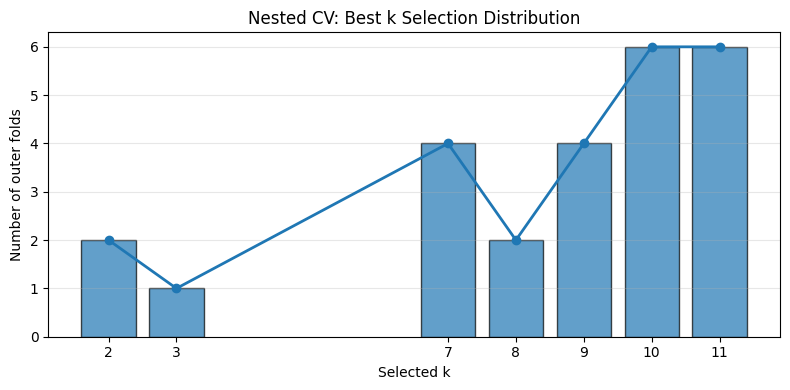

In [24]:
#best k plot 
best_k_counts = df_nested_results["best_k"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_k_counts.index, best_k_counts.values, edgecolor="black", alpha=0.7)

# Line tracing the distribution
plt.plot(best_k_counts.index, best_k_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected k")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best k Selection Distribution")
plt.xticks(best_k_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

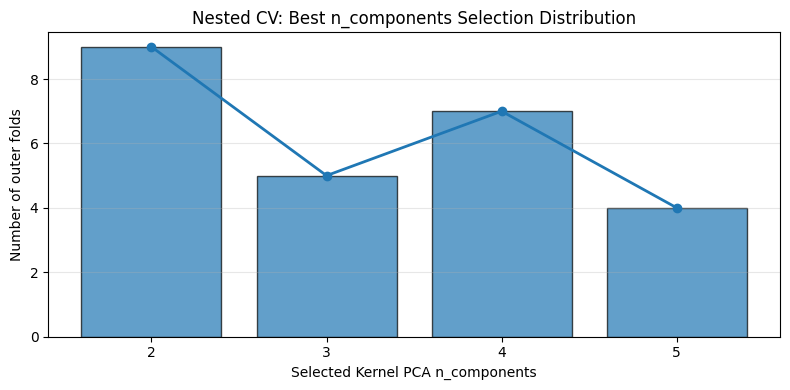

In [25]:
#best n components 
best_ncomp_counts = df_nested_results["best_n_components"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_ncomp_counts.index, best_ncomp_counts.values, edgecolor="black", alpha=0.7)
plt.plot(best_ncomp_counts.index, best_ncomp_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected Kernel PCA n_components")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best n_components Selection Distribution")
plt.xticks(best_ncomp_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

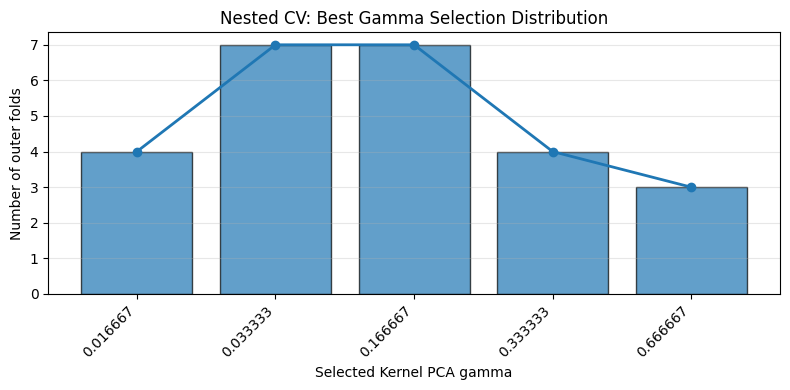

In [26]:
#
best_gamma_counts = df_nested_results["best_gamma"].value_counts().sort_index()

x_pos = np.arange(len(best_gamma_counts))

plt.figure(figsize=(8, 4))

plt.bar(x_pos, best_gamma_counts.values, edgecolor="black", alpha=0.7)
plt.plot(x_pos, best_gamma_counts.values, marker="o", linewidth=2)

plt.xticks(
    ticks=x_pos,
    labels=[f"{g:.6f}" for g in best_gamma_counts.index],
    rotation=45,
    ha="right"
)

plt.xlabel("Selected Kernel PCA gamma")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best Gamma Selection Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
hyperparameter_selection_summary = (
    df_nested_results
    .groupby(["best_n_components", "best_gamma", "best_k"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(hyperparameter_selection_summary)

,best_n_components,best_gamma,best_k,count
0,2,0.033333,10,3
1,2,0.033333,8,1
2,2,0.016667,11,1
3,2,0.033333,9,1
4,2,0.166667,10,1
5,2,0.166667,11,1
6,2,0.666667,2,1
7,3,0.016667,9,1
8,3,0.016667,11,1
9,3,0.033333,9,1


## 13. Nested CV Testing Score Distribution 

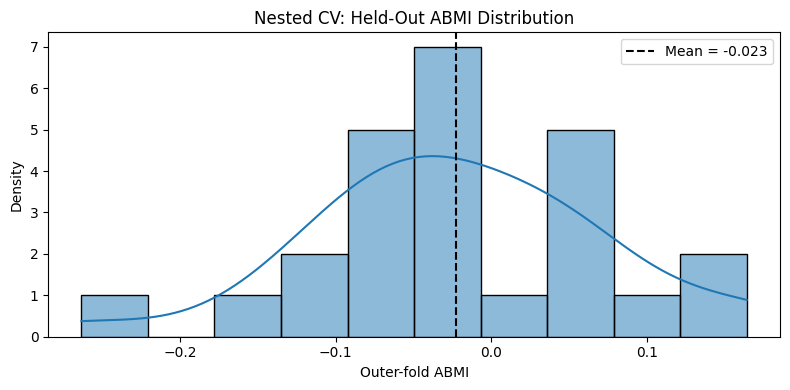

In [28]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ABMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ABMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ABMI'].mean():.3f}"
)

plt.xlabel("Outer-fold ABMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ABMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()

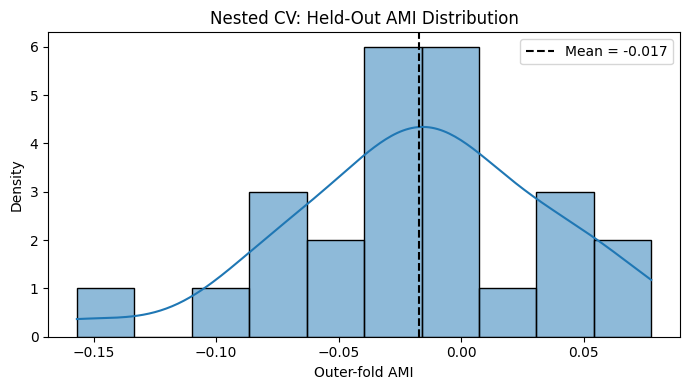

In [29]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_AMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_AMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_AMI'].mean():.3f}"
)

plt.xlabel("Outer-fold AMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out AMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()

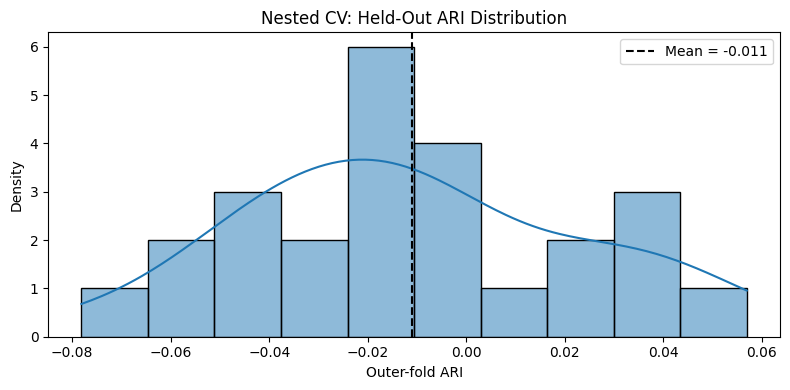

In [30]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ARI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ARI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ARI'].mean():.3f}"
)

plt.xlabel("Outer-fold ARI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ARI Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Residual Features — Filter and Collapse Duplicates

In [31]:
cortical_resid_features = [
    col for col in df_main.columns
    if col.startswith(("L_", "R_")) and col.endswith("_thickavg_resid")
]

subcortical_resid_features = [
    col for col in [
        "LLatVent_resid", "RLatVent_resid",
        "Lthal_resid",    "Rthal_resid",
        "Lcaud_resid",    "Rcaud_resid",
        "Lput_resid",     "Rput_resid",
        "Lpal_resid",     "Rpal_resid",
        "Lhippo_resid",   "Rhippo_resid",
        "Lamyg_resid",    "Ramyg_resid",
        "Laccumb_resid",  "Raccumb_resid",
    ]
    if col in df_main.columns
]

resid_features = cortical_resid_features + subcortical_resid_features

print(f"Cortical: {len(cortical_resid_features)}  "
      f"Subcortical: {len(subcortical_resid_features)}  "
      f"Total: {len(resid_features)}")


Cortical: 68  Subcortical: 16  Total: 84


## 15. Estimate Subject-Level Residual Slopes

In [32]:
df_resid_long = df_main[
    df_main["model_split_best"].isin(["train", "val"])
].copy()

req_resid_cols = ["subj_id", "time", "model_split_best", subtype_col] + resid_features

df_resid_long = df_resid_long.dropna(subset=req_resid_cols).copy()
df_resid_long[subtype_col] = df_resid_long[subtype_col].astype(int)

# Keep OFF and NaN; prefer OFF over NaN for same subj_id-time
df_resid = df_resid_long[
    df_resid_long["PDSTATE"].isna() |
    df_resid_long["PDSTATE"].astype(str).str.upper().eq("OFF")
].copy()

df_resid["pd_rank"] = df_resid["PDSTATE"].notna().astype(int)

df_resid_unique = (
    df_resid
    .sort_values(["subj_id", "time", "pd_rank"], ascending=[True, True, False])
    .drop_duplicates(subset=["subj_id", "time"], keep="first")
    .drop(columns="pd_rank")
    .copy()
)

df_resid_unique = df_resid_unique.dropna(subset=req_resid_cols).copy()
df_resid_unique[subtype_col] = df_resid_unique[subtype_col].astype(int)

print("Residual unique shape:", df_resid_unique.shape)
print("Unique subjects:", df_resid_unique["subj_id"].nunique())
print("Duplicate subject-time rows:", df_resid_unique.duplicated(subset=["subj_id", "time"]).sum())

Residual unique shape: (368, 261)
Unique subjects: 146
Duplicate subject-time rows: 0


In [33]:
resid_time_counts = (
    df_resid_unique
    .groupby("subj_id")["time"]
    .nunique()
    .reset_index(name="n_timepoints")
)

eligible_resid_subjects = resid_time_counts.loc[
    resid_time_counts["n_timepoints"] >= 2,
    "subj_id"
]

df_resid_slope_input = df_resid_unique[
    df_resid_unique["subj_id"].isin(eligible_resid_subjects)
].copy()

print("Residual subjects with ≥2 time points:", df_resid_slope_input["subj_id"].nunique())

Residual subjects with ≥2 time points: 118


## 16. Model 2 Dataset: Residual Slopes Only

In [34]:
df_resid_slopes = (
    df_resid_slope_input
    .groupby("subj_id")
    .apply(estimate_subject_slopes, features=resid_features)
    .reset_index(drop=True)
)

df_resid_slopes[subtype_col] = df_resid_slopes[subtype_col].astype(int)

resid_slope_cols = [f"{feature}_slope" for feature in resid_features]

print("Residual slopes shape:", df_resid_slopes.shape)
print("Number of residual slope features:", len(resid_slope_cols))

df_resid_slopes.head()

Residual slopes shape: (118, 175)
Number of residual slope features: 84


/tmp/ipykernel_5025/219367445.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resid_slope_input


,subj_id,n_timepoints,first_time,last_time,followup_duration,model_split_best,subtype_proba_best,L_bankssts_thickavg_resid_intercept,L_bankssts_thickavg_resid_slope,L_caudalanteriorcingulate_thickavg_resid_intercept,...,Rhippo_resid_intercept,Rhippo_resid_slope,Lamyg_resid_intercept,Lamyg_resid_slope,Ramyg_resid_intercept,Ramyg_resid_slope,Laccumb_resid_intercept,Laccumb_resid_slope,Raccumb_resid_intercept,Raccumb_resid_slope
0,3102,2,0,24,24,train,0,0.058607,-0.002065,-0.096382,...,8.644503,-11.180709,59.152798,-12.714793,88.880432,-11.227837,-39.227990,-3.000603,19.172502,-5.822576
1,3105,2,0,12,12,train,0,0.048566,0.012403,-0.150736,...,-338.045462,-10.247267,46.200502,-0.318233,28.266614,-16.464234,-106.697368,-0.103398,-30.350944,-2.765152
2,3107,4,0,48,48,val,0,0.138364,-0.000817,0.105329,...,181.500206,0.481281,-35.902168,-7.088847,-77.910964,-3.099652,21.649973,-2.523621,-13.845419,-0.854303
3,3108,3,0,48,48,train,0,0.231775,0.000464,0.125734,...,367.817894,-1.398656,289.731364,-5.149477,210.015174,-5.479531,71.293989,-1.353029,111.690732,-1.423516
4,3111,2,0,24,24,train,0,-0.161828,-0.002941,-0.230176,...,124.440939,-8.760712,113.506668,-2.994911,-313.108542,-1.378044,-186.182674,14.532924,-132.230509,2.419284


In [35]:
df_model_check_resid = df_resid_slopes.copy()

df_model_check_resid = df_model_check_resid[
    df_model_check_resid["model_split_best"].isin(["train", "val"])
].copy()

required_resid_cols = [
    "subj_id",
    "model_split_best",
    subtype_col,
] + resid_slope_cols

valid_resid_mask = (
    df_model_check_resid[required_resid_cols]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

df_model_resid = df_model_check_resid[valid_resid_mask].copy()

X_resid = df_model_resid[resid_slope_cols].copy()
y_resid = df_model_resid[subtype_col].values

df_model_resid["strat_label"] = (
    df_model_resid[subtype_col].astype(str)
    + "_"
    + df_model_resid["model_split_best"].astype(str)
)

strat_y_resid = df_model_resid["strat_label"].values

print("Residual X shape:", X_resid.shape)
print("Residual y shape:", y_resid.shape)

print("\nSubtype counts:")
print(df_model_resid[subtype_col].value_counts().sort_index())

print("\nSubtype × original split stratification counts:")
print(df_model_resid["strat_label"].value_counts().sort_index())

Residual X shape: (118, 84)
Residual y shape: (118,)

Subtype counts:
subtype_proba_best
0    49
1    48
2    21
Name: count, dtype: int64

Subtype × original split stratification counts:
strat_label
0_train    43
0_val       6
1_train    37
1_val      11
2_train    16
2_val       5
Name: count, dtype: int64


## 17. Run Nested CV: Residual Slopes Only

In [36]:
gamma_anchor = 1.0 / len(resid_slope_cols)

param_grid = {
    "kpca__n_components": [2, 3, 4, 5, 10, 20, 30, 50, 84],
    "kpca__gamma": [
        gamma_anchor * f
        for f in [2.0, 20, 40, 80]
    ],
    "kmeans__n_clusters": list(range(2, 12)),
}

n_param_combinations = (
    len(param_grid["kpca__n_components"])
    * len(param_grid["kpca__gamma"])
    * len(param_grid["kmeans__n_clusters"])
)

print("Gamma anchor:", gamma_anchor)
print("Number of hyperparameter combinations:", n_param_combinations)
param_grid

Gamma anchor: 0.011904761904761904
Number of hyperparameter combinations: 360


{'kpca__n_components': [2, 3, 4, 5, 10, 20, 30, 50, 84],
 'kpca__gamma': [0.023809523809523808,
  0.23809523809523808,
  0.47619047619047616,
  0.9523809523809523],
 'kmeans__n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

In [37]:
model_name = "Residual slopes only"

X = X_resid
y = y_resid
strat_y = strat_y_resid
feature_cols = resid_slope_cols

In [38]:
nested_results = []
best_param_results = []

outer_fold = 0

for outer_train_idx, outer_test_idx in outer_cv.split(X, strat_y):

    outer_fold += 1
    print("\n" + "=" * 60)
    print(f"Outer fold {outer_fold}")
    print("=" * 60)

    # Outer train/test split
    X_outer_train = X.iloc[outer_train_idx].copy()
    X_outer_test = X.iloc[outer_test_idx].copy()

    y_outer_train = y[outer_train_idx]
    y_outer_test = y[outer_test_idx]

    strat_outer_train = strat_y[outer_train_idx]

    print("Outer train size:", X_outer_train.shape[0])
    print("Outer test size:", X_outer_test.shape[0])
    
    # inner CV, built only using outer-traning data  
    # used by Gridsearch for hyperparameter selection 
    inner_cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=RANDOM_STATE
    )

    # Precompute inner splits using subtype × original split labels
    inner_splits = list(inner_cv.split(X_outer_train, strat_outer_train))

    # Inner loop: GridSearchCV
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit="ABMI",
        cv=inner_splits,
        n_jobs=-1,
        return_train_score=True,
        error_score=np.nan
    )

    gs.fit(X_outer_train, y_outer_train)

    best_model = gs.best_estimator_

    # Predict clusters for outer train and outer test
    outer_train_clusters = best_model.predict(X_outer_train)
    outer_test_clusters = best_model.predict(X_outer_test)

    # Outer- Fold AMI
    outer_train_ami = ami_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ami = ami_score(
        y_outer_test,
        outer_test_clusters
    )

    # Outer- Fold ABMI
    outer_train_abmi = abmi_score(
        y_outer_train,
        outer_train_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    outer_test_abmi = abmi_score(
        y_outer_test,
        outer_test_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    # Outer-fold ARI
    outer_train_ari = adjusted_rand_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ari = adjusted_rand_score(
        y_outer_test,
        outer_test_clusters
    )

    # Silhouette score in Kernel PCA space:
        # best model [:-1] means:
            #use the pipline up to the last step (KMeans)
            #so apply Standard scarler -> KernelPCA 
    Z_outer_train = best_model[:-1].transform(X_outer_train)
    Z_outer_test = best_model[:-1].transform(X_outer_test)

    n_train_clusters = len(np.unique(outer_train_clusters))
    n_test_clusters = len(np.unique(outer_test_clusters))

    outer_train_silhouette = (
        silhouette_score(Z_outer_train, outer_train_clusters)
        if 1 < n_train_clusters < len(Z_outer_train)
        else np.nan
    )

    outer_test_silhouette = (
        silhouette_score(Z_outer_test, outer_test_clusters)
        if 1 < n_test_clusters < len(Z_outer_test)
        else np.nan
    )

    # Store results
    result_row = {
        "outer_fold": outer_fold,

        "inner_best_ABMI": gs.best_score_,

        "outer_train_AMI": outer_train_ami,
        "outer_test_AMI": outer_test_ami,

        "outer_train_ABMI": outer_train_abmi,
        "outer_test_ABMI": outer_test_abmi,

        "outer_train_ARI": outer_train_ari,
        "outer_test_ARI": outer_test_ari,

        "outer_train_silhouette": outer_train_silhouette,
        "outer_test_silhouette": outer_test_silhouette,

        "best_n_components": gs.best_params_["kpca__n_components"],
        "best_gamma": gs.best_params_["kpca__gamma"],
        "best_k": gs.best_params_["kmeans__n_clusters"],

        "n_outer_train": X_outer_train.shape[0],
        "n_outer_test": X_outer_test.shape[0],
        "inner_n_splits": 5,
    }

    nested_results.append(result_row)

    best_param_results.append({
        "outer_fold": outer_fold,
        **gs.best_params_,
        "inner_best_ABMI": gs.best_score_,
    })

    print("Best parameters:", gs.best_params_)
    print(f"Inner best ABMI: {gs.best_score_:.4f}")
    print(f"Outer test AMI : {outer_test_ami:.4f}")
    print(f"Outer test ABMI: {outer_test_abmi:.4f}")
    print(f"Outer test ARI : {outer_test_ari:.4f}")


Outer fold 1
Outer train size: 94
Outer test size: 24


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 5400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-p

Best parameters: {'kmeans__n_clusters': 2, 'kpca__gamma': 0.023809523809523808, 'kpca__n_components': 3}
Inner best ABMI: 0.0693
Outer test AMI : -0.0271
Outer test ABMI: -0.0088
Outer test ARI : -0.0536

Outer fold 2
Outer train size: 94
Outer test size: 24


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 5400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-p

Best parameters: {'kmeans__n_clusters': 11, 'kpca__gamma': 0.023809523809523808, 'kpca__n_components': 10}
Inner best ABMI: 0.0813
Outer test AMI : -0.0404
Outer test ABMI: -0.0868
Outer test ARI : -0.0154

Outer fold 3
Outer train size: 94
Outer test size: 24


...

Best parameters: {'kmeans__n_clusters': 10, 'kpca__gamma': 0.023809523809523808, 'kpca__n_components': 2}
Inner best ABMI: 0.0794
Outer test AMI : 0.0048
Outer test ABMI: 0.0145
Outer test ARI : -0.0226

Outer fold 24
Outer train size: 95
Outer test size: 23


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 5400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-p

Best parameters: {'kmeans__n_clusters': 11, 'kpca__gamma': 0.023809523809523808, 'kpca__n_components': 2}
Inner best ABMI: 0.1280
Outer test AMI : -0.0365
Outer test ABMI: -0.1153
Outer test ARI : -0.0277

Outer fold 25
Outer train size: 95
Outer test size: 23


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 5400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-p

Best parameters: {'kmeans__n_clusters': 10, 'kpca__gamma': 0.023809523809523808, 'kpca__n_components': 2}
Inner best ABMI: 0.0511
Outer test AMI : 0.1142
Outer test ABMI: 0.2265
Outer test ARI : 0.0401


## 18. Model 2 Results 

In [39]:
df_nested_results = pd.DataFrame(nested_results)
df_best_params = pd.DataFrame(best_param_results)

display(df_nested_results)
display(df_best_params)

# Check for any NaN values — if all zeros, no kPCA numerical failures occurred
print("NaN check:")
print(df_nested_results.isna().sum())


,outer_fold,inner_best_ABMI,outer_train_AMI,outer_test_AMI,outer_train_ABMI,outer_test_ABMI,outer_train_ARI,outer_test_ARI,outer_train_silhouette,outer_test_silhouette,best_n_components,best_gamma,best_k,n_outer_train,n_outer_test,inner_n_splits
0,1,0.069281,-0.003792,-0.027087,-0.001845,-0.008759,-0.003013,-0.053631,0.337212,0.304641,3,0.02381,2,94,24,5
1,2,0.081305,-0.033743,-0.040420,-0.066181,-0.086848,-0.010224,-0.015391,0.226791,0.117373,10,0.02381,11,94,24,5
2,3,0.097272,0.029555,-0.011817,0.064300,0.016063,0.011340,-0.018816,0.505589,0.358659,2,0.02381,8,94,24,5
3,4,0.049637,0.037425,0.101076,0.038516,0.216740,0.000466,-0.004992,0.094230,0.174358,20,0.02381,7,95,23,5
4,5,0.121868,-0.000877,0.052164,0.011387,0.064077,0.018666,-0.030877,0.388064,0.425593,4,0.02381,11,95,23,5
5,6,0.065253,-0.025675,-0.076786,-0.048500,-0.137370,0.006866,-0.049866,0.509901,0.269310,2,0.02381,9,94,24,5
6,7,0.055243,-0.009554,0.056336,-0.014615,0.122351,-0.000318,0.005967,0.042771,0.251257,30,0.02381,11,94,24,5
7,8,0.086051,0.001371,0.055107,-0.003969,0.171198,0.005961,-0.029421,0.102677,0.127328,10,0.02381,2,94,24,5
8,9,0.082758,0.020546,-0.018594,0.040112,-0.025241,0.012608,0.014224,0.505024,0.443997,2,0.02381,7,95,23,5
9,10,0.057128,-0.021470,-0.083567,-0.031422,-0.139826,-0.003717,-0.047651,0.056839,0.038660,20,0.02381,5,95,23,5


,outer_fold,kmeans__n_clusters,kpca__gamma,kpca__n_components,inner_best_ABMI
0,1,2,0.02381,3,0.069281
1,2,11,0.02381,10,0.081305
2,3,8,0.02381,2,0.097272
3,4,7,0.02381,20,0.049637
4,5,11,0.02381,4,0.121868
5,6,9,0.02381,2,0.065253
6,7,11,0.02381,30,0.055243
7,8,2,0.02381,10,0.086051
8,9,7,0.02381,2,0.082758
9,10,5,0.02381,20,0.057128


NaN check:
outer_fold                0
inner_best_ABMI           0
outer_train_AMI           0
outer_test_AMI            0
outer_train_ABMI          0
outer_test_ABMI           0
outer_train_ARI           0
outer_test_ARI            0
outer_train_silhouette    0
outer_test_silhouette     1
best_n_components         0
best_gamma                0
best_k                    0
n_outer_train             0
n_outer_test              0
inner_n_splits            0
dtype: int64


In [40]:
metric_cols = [
    "outer_test_AMI",
    "outer_test_ABMI",
    "outer_test_ARI",
    "outer_test_silhouette",
]

nested_metric_summary = (
    df_nested_results[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .T
)

display(nested_metric_summary)

print("Nested CV held-out performance summary:")
print(nested_metric_summary.to_string())



,mean,std,min,max
outer_test_AMI,-0.014452,0.060946,-0.140021,0.114194
outer_test_ABMI,-0.017544,0.123515,-0.271574,0.226526
outer_test_ARI,-0.017874,0.032191,-0.075715,0.050803
outer_test_silhouette,0.290793,0.127555,0.038660,0.462353


Nested CV held-out performance summary:
                           mean       std       min       max
outer_test_AMI        -0.014452  0.060946 -0.140021  0.114194
outer_test_ABMI       -0.017544  0.123515 -0.271574  0.226526
outer_test_ARI        -0.017874  0.032191 -0.075715  0.050803
outer_test_silhouette  0.290793  0.127555  0.038660  0.462353


In [41]:

# Hyperparameter Selection Distribution 


print("Best k distribution:")
display(df_nested_results["best_k"].value_counts().sort_index())

print("Best n_components distribution:")
display(df_nested_results["best_n_components"].value_counts().sort_index())

print("Best gamma distribution:")
display(df_nested_results["best_gamma"].value_counts().sort_index())



Best k distribution:


best_k
2     3
5     2
7     2
8     4
9     2
10    6
11    6
Name: count, dtype: int64

Best n_components distribution:


best_n_components
2     12
3      1
4      1
5      2
10     2
20     4
30     3
Name: count, dtype: int64

Best gamma distribution:


best_gamma
0.02381    25
Name: count, dtype: int64

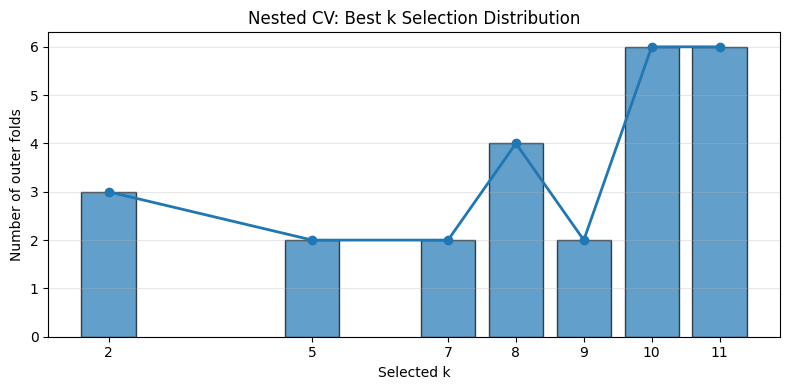

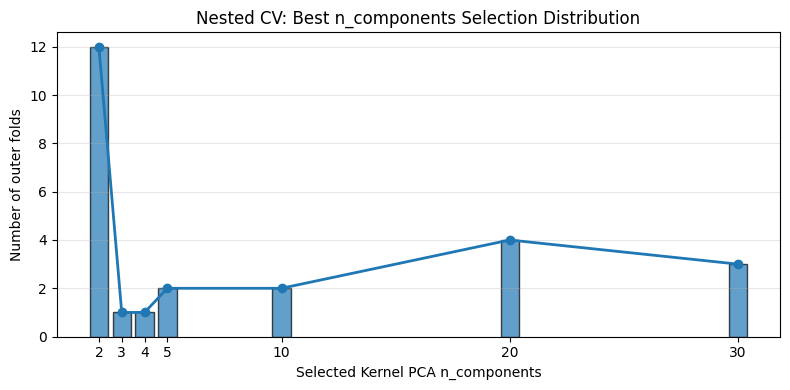

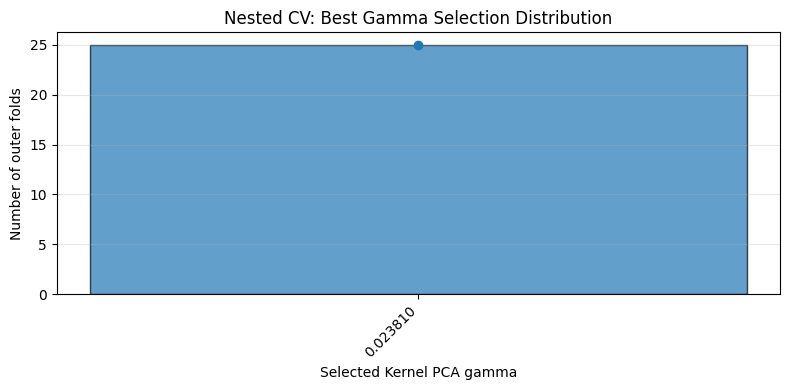

,best_n_components,best_gamma,best_k,count
0,2,0.02381,8,3
1,2,0.02381,10,3
2,2,0.02381,11,3
3,2,0.02381,9,2
4,30,0.02381,10,2
5,20,0.02381,5,2
6,2,0.02381,7,1
7,3,0.02381,2,1
8,5,0.02381,2,1
9,4,0.02381,11,1


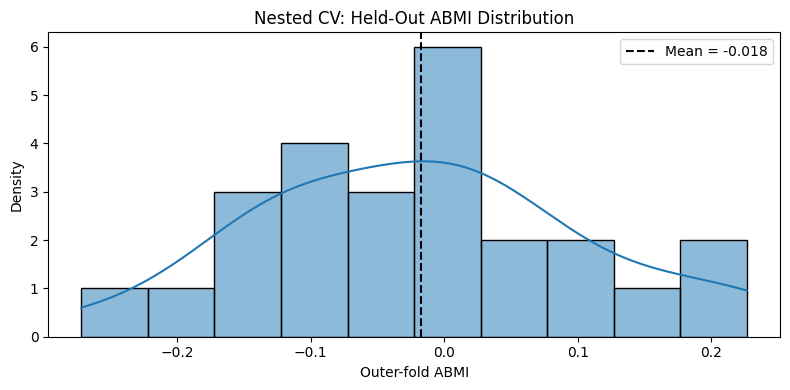

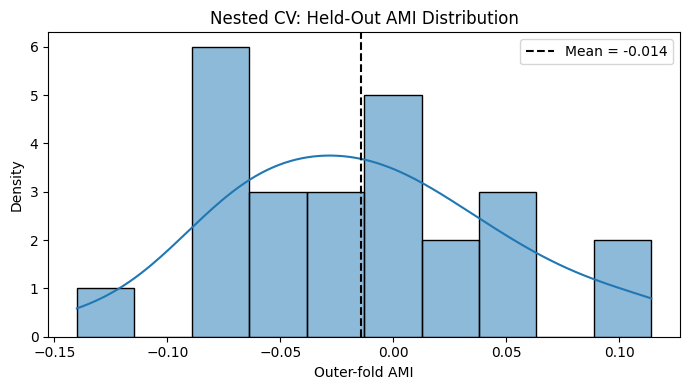

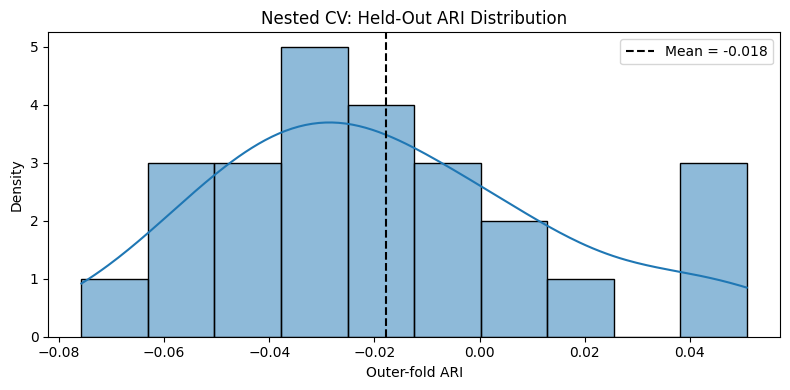

In [42]:

#best k plot 
best_k_counts = df_nested_results["best_k"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_k_counts.index, best_k_counts.values, edgecolor="black", alpha=0.7)

# Line tracing the distribution
plt.plot(best_k_counts.index, best_k_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected k")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best k Selection Distribution")
plt.xticks(best_k_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#best n components 
best_ncomp_counts = df_nested_results["best_n_components"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_ncomp_counts.index, best_ncomp_counts.values, edgecolor="black", alpha=0.7)
plt.plot(best_ncomp_counts.index, best_ncomp_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected Kernel PCA n_components")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best n_components Selection Distribution")
plt.xticks(best_ncomp_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best_gamma_counts = df_nested_results["best_gamma"].value_counts().sort_index()

x_pos = np.arange(len(best_gamma_counts))

plt.figure(figsize=(8, 4))

plt.bar(x_pos, best_gamma_counts.values, edgecolor="black", alpha=0.7)
plt.plot(x_pos, best_gamma_counts.values, marker="o", linewidth=2)

plt.xticks(
    ticks=x_pos,
    labels=[f"{g:.6f}" for g in best_gamma_counts.index],
    rotation=45,
    ha="right"
)

plt.xlabel("Selected Kernel PCA gamma")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best Gamma Selection Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


hyperparameter_selection_summary = (
    df_nested_results
    .groupby(["best_n_components", "best_gamma", "best_k"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(hyperparameter_selection_summary)


# ## 13. Nested CV Testing Score Distribution 
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ABMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ABMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ABMI'].mean():.3f}"
)

plt.xlabel("Outer-fold ABMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ABMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_AMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_AMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_AMI'].mean():.3f}"
)

plt.xlabel("Outer-fold AMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out AMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ARI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ARI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ARI'].mean():.3f}"
)

plt.xlabel("Outer-fold ARI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ARI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


## 19. Model 3 Dataset: Clinical + Residual Slopes

In [43]:
df_combined_slopes = pd.merge(
    df_clinical_slopes[
        ["subj_id", "model_split_best", subtype_col, "n_timepoints", "followup_duration"]
        + clinical_slope_cols
    ],
    df_resid_slopes[
        ["subj_id"] + resid_slope_cols
    ],
    on="subj_id",
    how="inner"
)

combined_feature_cols = clinical_slope_cols + resid_slope_cols

print("Combined slopes shape:", df_combined_slopes.shape)
print("Number of combined features:", len(combined_feature_cols))
print("Subjects in combined model:", df_combined_slopes["subj_id"].nunique())

Combined slopes shape: (118, 92)
Number of combined features: 87
Subjects in combined model: 118


In [44]:
df_model_check_combined = df_combined_slopes.copy()

df_model_check_combined = df_model_check_combined[
    df_model_check_combined["model_split_best"].isin(["train", "val"])
].copy()

required_combined_cols = [
    "subj_id",
    "model_split_best",
    subtype_col,
] + combined_feature_cols

valid_combined_mask = (
    df_model_check_combined[required_combined_cols]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

df_model_combined = df_model_check_combined[valid_combined_mask].copy()

X_combined = df_model_combined[combined_feature_cols].copy()
y_combined = df_model_combined[subtype_col].values

df_model_combined["strat_label"] = (
    df_model_combined[subtype_col].astype(str)
    + "_"
    + df_model_combined["model_split_best"].astype(str)
)

strat_y_combined = df_model_combined["strat_label"].values

print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)

print("\nSubtype counts:")
print(df_model_combined[subtype_col].value_counts().sort_index())

print("\nSubtype × original split stratification counts:")
print(df_model_combined["strat_label"].value_counts().sort_index())

Combined X shape: (118, 87)
Combined y shape: (118,)

Subtype counts:
subtype_proba_best
0    49
1    48
2    21
Name: count, dtype: int64

Subtype × original split stratification counts:
strat_label
0_train    43
0_val       6
1_train    37
1_val      11
2_train    16
2_val       5
Name: count, dtype: int64


In [45]:
df_model_check_combined = df_combined_slopes.copy()

df_model_check_combined = df_model_check_combined[
    df_model_check_combined["model_split_best"].isin(["train", "val"])
].copy()

required_combined_cols = [
    "subj_id",
    "model_split_best",
    subtype_col,
] + combined_feature_cols

valid_combined_mask = (
    df_model_check_combined[required_combined_cols]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
    .all(axis=1)
)

df_model_combined = df_model_check_combined[valid_combined_mask].copy()

X_combined = df_model_combined[combined_feature_cols].copy()
y_combined = df_model_combined[subtype_col].values

df_model_combined["strat_label"] = (
    df_model_combined[subtype_col].astype(str)
    + "_"
    + df_model_combined["model_split_best"].astype(str)
)

strat_y_combined = df_model_combined["strat_label"].values

print("Combined X shape:", X_combined.shape)
print("Combined y shape:", y_combined.shape)

print("\nSubtype counts:")
print(df_model_combined[subtype_col].value_counts().sort_index())

print("\nSubtype × original split stratification counts:")
print(df_model_combined["strat_label"].value_counts().sort_index())

Combined X shape: (118, 87)
Combined y shape: (118,)

Subtype counts:
subtype_proba_best
0    49
1    48
2    21
Name: count, dtype: int64

Subtype × original split stratification counts:
strat_label
0_train    43
0_val       6
1_train    37
1_val      11
2_train    16
2_val       5
Name: count, dtype: int64


In [46]:
gamma_anchor = 1.0 / len(combined_feature_cols)

param_grid = {
    "kpca__n_components": [2, 3, 5, 10, 20, 30, 50, 87],
    "kpca__gamma": [
        gamma_anchor * f
        for f in [ 1.0, 2.0, 5, 10, 20]
    ],
    "kmeans__n_clusters": list(range(2, 12)),
}

n_param_combinations = (
    len(param_grid["kpca__n_components"])
    * len(param_grid["kpca__gamma"])
    * len(param_grid["kmeans__n_clusters"])
)

print("Gamma anchor:", gamma_anchor)
print("Number of hyperparameter combinations:", n_param_combinations)
param_grid

Gamma anchor: 0.011494252873563218
Number of hyperparameter combinations: 400


{'kpca__n_components': [2, 3, 5, 10, 20, 30, 50, 87],
 'kpca__gamma': [0.011494252873563218,
  0.022988505747126436,
  0.05747126436781609,
  0.11494252873563218,
  0.22988505747126436],
 'kmeans__n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

In [47]:
model_name = "Clinical + residual slopes"

X = X_combined
y = y_combined
strat_y = strat_y_combined
feature_cols = combined_feature_cols

In [48]:
nested_results = []
best_param_results = []

outer_fold = 0

for outer_train_idx, outer_test_idx in outer_cv.split(X, strat_y):

    outer_fold += 1
    print("\n" + "=" * 60)
    print(f"Outer fold {outer_fold}")
    print("=" * 60)

    # Outer train/test split
    X_outer_train = X.iloc[outer_train_idx].copy()
    X_outer_test = X.iloc[outer_test_idx].copy()

    y_outer_train = y[outer_train_idx]
    y_outer_test = y[outer_test_idx]

    strat_outer_train = strat_y[outer_train_idx]

    print("Outer train size:", X_outer_train.shape[0])
    print("Outer test size:", X_outer_test.shape[0])
    
    # inner CV, built only using outer-traning data  
    # used by Gridsearch for hyperparameter selection 
    inner_cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=RANDOM_STATE
    )

    # Precompute inner splits using subtype × original split labels
    inner_splits = list(inner_cv.split(X_outer_train, strat_outer_train))

    # Inner loop: GridSearchCV
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        refit="ABMI",
        cv=inner_splits,
        n_jobs=-1,
        return_train_score=True,
        error_score=np.nan
    )

    gs.fit(X_outer_train, y_outer_train)

    best_model = gs.best_estimator_

    # Predict clusters for outer train and outer test
    outer_train_clusters = best_model.predict(X_outer_train)
    outer_test_clusters = best_model.predict(X_outer_test)

    # Outer- Fold AMI
    outer_train_ami = ami_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ami = ami_score(
        y_outer_test,
        outer_test_clusters
    )

    # Outer- Fold ABMI
    outer_train_abmi = abmi_score(
        y_outer_train,
        outer_train_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    outer_test_abmi = abmi_score(
        y_outer_test,
        outer_test_clusters,
        n_permutations=200,
        random_state=RANDOM_STATE
    )

    # Outer-fold ARI
    outer_train_ari = adjusted_rand_score(
        y_outer_train,
        outer_train_clusters
    )

    outer_test_ari = adjusted_rand_score(
        y_outer_test,
        outer_test_clusters
    )

    # Silhouette score in Kernel PCA space:
        # best model [:-1] means:
            #use the pipline up to the last step (KMeans)
            #so apply Standard scarler -> KernelPCA 
    Z_outer_train = best_model[:-1].transform(X_outer_train)
    Z_outer_test = best_model[:-1].transform(X_outer_test)

    n_train_clusters = len(np.unique(outer_train_clusters))
    n_test_clusters = len(np.unique(outer_test_clusters))

    outer_train_silhouette = (
        silhouette_score(Z_outer_train, outer_train_clusters)
        if 1 < n_train_clusters < len(Z_outer_train)
        else np.nan
    )

    outer_test_silhouette = (
        silhouette_score(Z_outer_test, outer_test_clusters)
        if 1 < n_test_clusters < len(Z_outer_test)
        else np.nan
    )

    # Store results
    result_row = {
        "outer_fold": outer_fold,

        "inner_best_ABMI": gs.best_score_,

        "outer_train_AMI": outer_train_ami,
        "outer_test_AMI": outer_test_ami,

        "outer_train_ABMI": outer_train_abmi,
        "outer_test_ABMI": outer_test_abmi,

        "outer_train_ARI": outer_train_ari,
        "outer_test_ARI": outer_test_ari,

        "outer_train_silhouette": outer_train_silhouette,
        "outer_test_silhouette": outer_test_silhouette,

        "best_n_components": gs.best_params_["kpca__n_components"],
        "best_gamma": gs.best_params_["kpca__gamma"],
        "best_k": gs.best_params_["kmeans__n_clusters"],

        "n_outer_train": X_outer_train.shape[0],
        "n_outer_test": X_outer_test.shape[0],
        "inner_n_splits": 5,
    }

    nested_results.append(result_row)

    best_param_results.append({
        "outer_fold": outer_fold,
        **gs.best_params_,
        "inner_best_ABMI": gs.best_score_,
    })

    print("Best parameters:", gs.best_params_)
    print(f"Inner best ABMI: {gs.best_score_:.4f}")
    print(f"Outer test AMI : {outer_test_ami:.4f}")
    print(f"Outer test ABMI: {outer_test_abmi:.4f}")
    print(f"Outer test ARI : {outer_test_ari:.4f}")


Outer fold 1
Outer train size: 94
Outer test size: 24


Best parameters: {'kmeans__n_clusters': 7, 'kpca__gamma': 0.022988505747126436, 'kpca__n_components': 2}
Inner best ABMI: 0.1019
Outer test AMI : 0.0778
Outer test ABMI: 0.1904
Outer test ARI : 0.0301

Outer fold 2
Outer train size: 94
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 5, 'kpca__gamma': 0.11494252873563218, 'kpca__n_components': 30}
Inner best ABMI: 0.0610
Outer test AMI : 0.0000
Outer test ABMI: 0.0000
Outer test ARI : 0.0000

Outer fold 3
Outer train size: 94
Outer test size: 24
Best parameters: {'kmeans__n_clusters': 7, 'kpca__gamma': 0.022988505747126436, 'kpca__n_components': 2}
Inner best ABMI: 0.1279
Outer test AMI : -0.0454
Outer test ABMI: -0.0656
Outer test ARI : -0.0312

Outer fold 4
Outer train size: 95
Outer test size: 23
Best parameters: {'kmeans__n_clusters': 4, 'kpca__gamma': 0.011494252873563218, 'kpca__n_components': 87}
Inner best ABMI: 0.0539
Outer test AMI : 0.0000
Outer test ABMI: 0.0000
Outer test ARI : 0.0000

Outer fold 5
Outer train s

In [49]:
df_nested_results = pd.DataFrame(nested_results)
df_best_params = pd.DataFrame(best_param_results)

display(df_nested_results)
display(df_best_params)

# Check for any NaN values — if all zeros, no kPCA numerical failures occurred
print("NaN check:")
print(df_nested_results.isna().sum())


,outer_fold,inner_best_ABMI,outer_train_AMI,outer_test_AMI,outer_train_ABMI,outer_test_ABMI,outer_train_ARI,outer_test_ARI,outer_train_silhouette,outer_test_silhouette,best_n_components,best_gamma,best_k,n_outer_train,n_outer_test,inner_n_splits
0,1,0.101862,0.009065,0.077775,0.028156,0.190424,0.005369,0.030120,0.510898,0.404790,2,0.022989,7,94,24,5
1,2,0.061046,0.002885,0.000000,0.027314,0.000000,0.029827,0.000000,0.160977,NaN,30,0.114943,5,94,24,5
2,3,0.127877,0.021141,-0.045374,0.043478,-0.065566,0.012724,-0.031189,0.513276,0.382425,2,0.022989,7,94,24,5
3,4,0.053943,-0.008451,0.000000,-0.045667,0.000000,-0.008590,0.000000,0.020343,NaN,87,0.011494,4,95,23,5
4,5,0.106132,0.003507,-0.070248,0.001825,-0.113663,0.015144,-0.081237,0.243564,0.264264,5,0.011494,11,95,23,5
5,6,0.062214,-0.001904,0.000000,-0.003670,0.000000,-0.002060,0.000000,0.012612,NaN,87,0.022989,7,94,24,5
6,7,0.086161,0.004675,-0.046248,0.012409,-0.072357,-0.020599,-0.005280,0.334095,0.352488,5,0.057471,2,94,24,5
7,8,0.095267,-0.002844,0.131722,-0.001590,0.313603,-0.011508,0.069449,0.216141,0.251751,10,0.057471,2,94,24,5
8,9,0.134313,0.015665,-0.024878,0.019578,-0.014952,0.018382,0.007032,0.503830,0.254492,2,0.022989,10,95,23,5
9,10,0.076152,-0.005706,0.001079,-0.004642,0.019543,-0.020053,0.057269,-0.026251,0.065596,50,0.011494,11,95,23,5


,outer_fold,kmeans__n_clusters,kpca__gamma,kpca__n_components,inner_best_ABMI
0,1,7,0.022989,2,0.101862
1,2,5,0.114943,30,0.061046
2,3,7,0.022989,2,0.127877
3,4,4,0.011494,87,0.053943
4,5,11,0.011494,5,0.106132
5,6,7,0.022989,87,0.062214
6,7,2,0.057471,5,0.086161
7,8,2,0.057471,10,0.095267
8,9,10,0.022989,2,0.134313
9,10,11,0.011494,50,0.076152


NaN check:
outer_fold                0
inner_best_ABMI           0
outer_train_AMI           0
outer_test_AMI            0
outer_train_ABMI          0
outer_test_ABMI           0
outer_train_ARI           0
outer_test_ARI            0
outer_train_silhouette    0
outer_test_silhouette     4
best_n_components         0
best_gamma                0
best_k                    0
n_outer_train             0
n_outer_test              0
inner_n_splits            0
dtype: int64


In [50]:

metric_cols = [
    "outer_test_AMI",
    "outer_test_ABMI",
    "outer_test_ARI",
    "outer_test_silhouette",
]

nested_metric_summary = (
    df_nested_results[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .T
)

display(nested_metric_summary)

print("Nested CV held-out performance summary:")
print(nested_metric_summary.to_string())



,mean,std,min,max
outer_test_AMI,-0.008819,0.065480,-0.127632,0.131722
outer_test_ABMI,-0.001320,0.129115,-0.239764,0.313603
outer_test_ARI,-0.005304,0.048881,-0.081237,0.097692
outer_test_silhouette,0.327096,0.127347,0.065596,0.569708


Nested CV held-out performance summary:
                           mean       std       min       max
outer_test_AMI        -0.008819  0.065480 -0.127632  0.131722
outer_test_ABMI       -0.001320  0.129115 -0.239764  0.313603
outer_test_ARI        -0.005304  0.048881 -0.081237  0.097692
outer_test_silhouette  0.327096  0.127347  0.065596  0.569708


In [51]:

# Hyperparameter Selection Distribution 


print("Best k distribution:")
display(df_nested_results["best_k"].value_counts().sort_index())

print("Best n_components distribution:")
display(df_nested_results["best_n_components"].value_counts().sort_index())

print("Best gamma distribution:")
display(df_nested_results["best_gamma"].value_counts().sort_index())


Best k distribution:


best_k
2     5
4     1
5     1
6     1
7     4
8     3
9     1
10    3
11    6
Name: count, dtype: int64

Best n_components distribution:


best_n_components
2     11
3      3
5      3
10     1
20     2
30     1
50     1
87     3
Name: count, dtype: int64

Best gamma distribution:


best_gamma
0.011494     8
0.022989    10
0.057471     6
0.114943     1
Name: count, dtype: int64

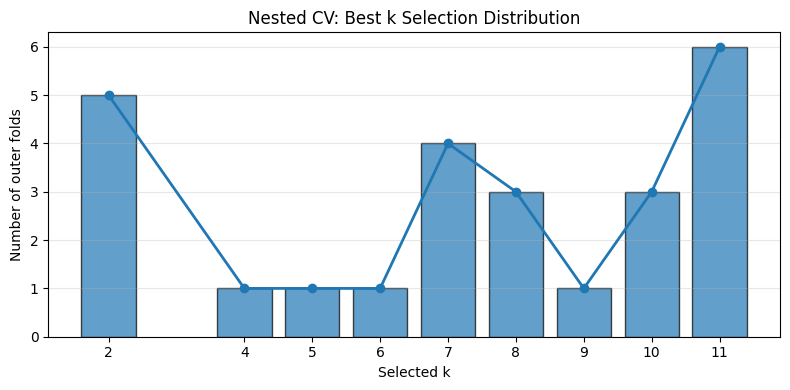

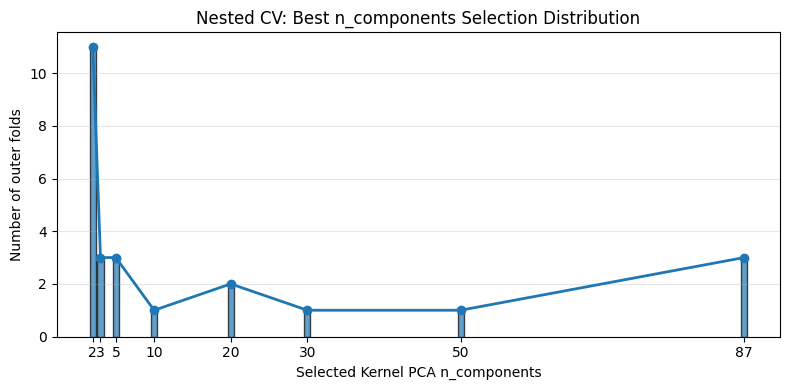

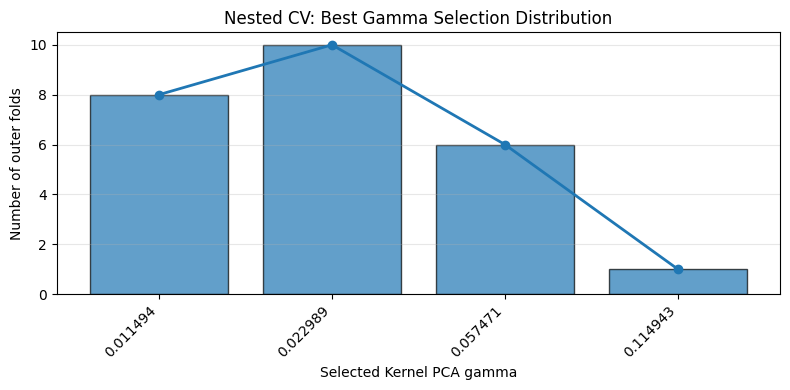

,best_n_components,best_gamma,best_k,count
0,2,0.022989,7,2
1,2,0.022989,10,2
2,2,0.057471,2,2
3,5,0.057471,2,2
4,2,0.011494,8,1
5,2,0.022989,9,1
6,2,0.011494,11,1
7,2,0.057471,11,1
8,2,0.022989,11,1
9,3,0.011494,6,1


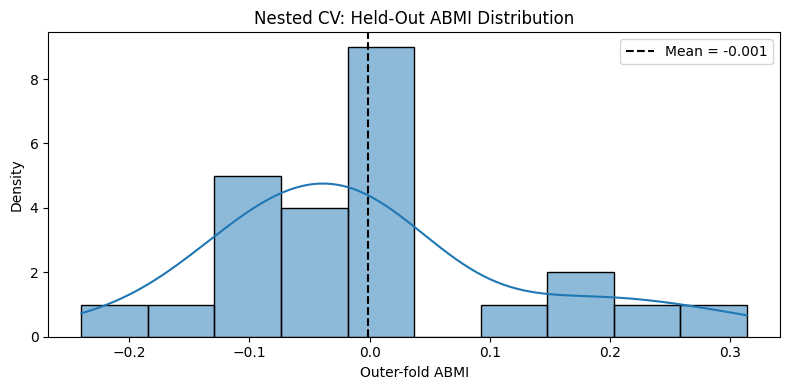

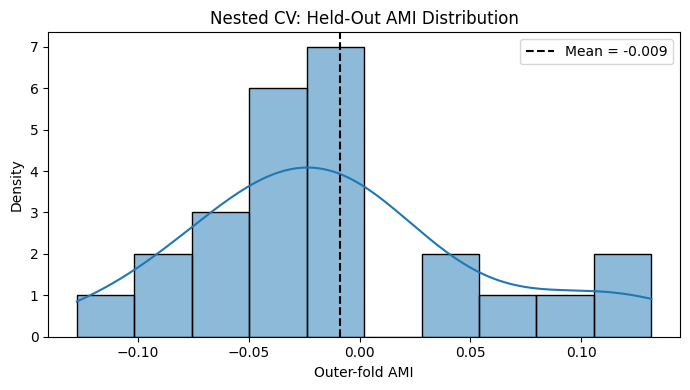

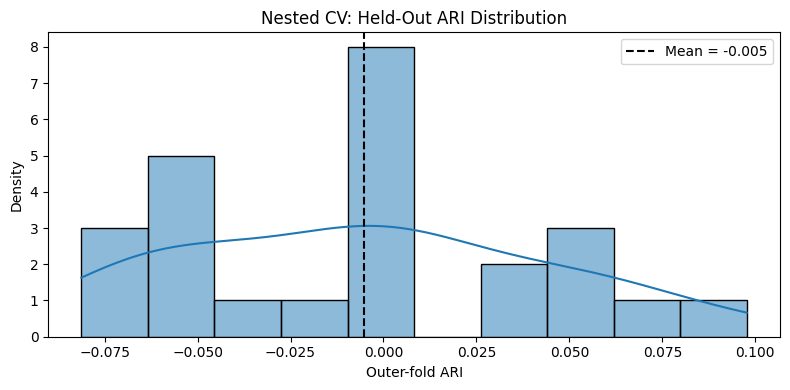

In [52]:


#best k plot 
best_k_counts = df_nested_results["best_k"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_k_counts.index, best_k_counts.values, edgecolor="black", alpha=0.7)

# Line tracing the distribution
plt.plot(best_k_counts.index, best_k_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected k")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best k Selection Distribution")
plt.xticks(best_k_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#best n components 
best_ncomp_counts = df_nested_results["best_n_components"].value_counts().sort_index()

plt.figure(figsize=(8, 4))

plt.bar(best_ncomp_counts.index, best_ncomp_counts.values, edgecolor="black", alpha=0.7)
plt.plot(best_ncomp_counts.index, best_ncomp_counts.values, marker="o", linewidth=2)

plt.xlabel("Selected Kernel PCA n_components")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best n_components Selection Distribution")
plt.xticks(best_ncomp_counts.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best_gamma_counts = df_nested_results["best_gamma"].value_counts().sort_index()

x_pos = np.arange(len(best_gamma_counts))

plt.figure(figsize=(8, 4))

plt.bar(x_pos, best_gamma_counts.values, edgecolor="black", alpha=0.7)
plt.plot(x_pos, best_gamma_counts.values, marker="o", linewidth=2)

plt.xticks(
    ticks=x_pos,
    labels=[f"{g:.6f}" for g in best_gamma_counts.index],
    rotation=45,
    ha="right"
)

plt.xlabel("Selected Kernel PCA gamma")
plt.ylabel("Number of outer folds")
plt.title("Nested CV: Best Gamma Selection Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


hyperparameter_selection_summary = (
    df_nested_results
    .groupby(["best_n_components", "best_gamma", "best_k"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(hyperparameter_selection_summary)


# ## 13. Nested CV Testing Score Distribution 
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ABMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ABMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ABMI'].mean():.3f}"
)

plt.xlabel("Outer-fold ABMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ABMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_AMI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_AMI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_AMI'].mean():.3f}"
)

plt.xlabel("Outer-fold AMI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out AMI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_nested_results,
    x="outer_test_ARI",
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    df_nested_results["outer_test_ARI"].mean(),
    linestyle="--",
    color="black",
    label=f"Mean = {df_nested_results['outer_test_ARI'].mean():.3f}"
)

plt.xlabel("Outer-fold ARI")
plt.ylabel("Density")
plt.title("Nested CV: Held-Out ARI Distribution")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
notebook_elapsed = time.time() - notebook_start_time
hours = int(notebook_elapsed // 3600)
minutes = int((notebook_elapsed % 3600) // 60)
seconds = int(notebook_elapsed % 60)
print(f"Total notebook runtime: {hours}h {minutes}m {seconds}s")

Total notebook runtime: 0h 43m 34s
